### NPi recontruction using all features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from scipy.optimize import curve_fit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


In [ ]:
df = pd.read_csv("../Modified_Pupilometri/NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})
df["redcap_repeat_instance"] = df["redcap_repeat_instance"].fillna(0).astype(int)

df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])



df_l = pd.read_csv("../Pupilometri/HC_left_NPi.csv")
df_r = pd.read_csv("../Pupilometri/HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)


def z_score(x, mean, std):
    return (x - mean) / std

# Get z-scpres for all features
df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df["z_const_velocity"] = z_score(df["const_velocity"], df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
df["z_max_const_velocity"] = z_score(df["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df["z_dilat_velocity"] = z_score(df["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df["z_latency"] = z_score(df["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())

TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch",
    "z_const_velocity",
    "z_max_const_velocity",
    "z_latency",
    "z_dilat_velocity"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values



X_trans = X.copy()


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Pupil min model
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# pupil size model
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

# CH model
def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b



# Stratified CV setup

y_binned = pd.qcut(df["npi"], q=5, labels=False, duplicates="drop")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores, mae_scores, r2_scores = [], [], []

all_true = []
all_pred = []
all_indices = []
all_repeat = []
all_eye = []

# CV LOOP

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_trans, y_binned, groups)
):

    print(f"\n--- Fold {fold+1} ---")

    X_train = X_trans.iloc[train_idx]
    X_test  = X_trans.iloc[test_idx]

    y_train_raw = y_raw[train_idx]
    y_test_raw  = y_raw[test_idx]

    # Logit transform
    y_train_scaled = np.clip(y_train_raw / 5, 1e-6, 1-1e-6)
    z_train = np.log(y_train_scaled / (1 - y_train_scaled))


    # Train GAM
    gam = LinearGAM(
        s(0, n_splines=20) +
        s(1, constraints='monotonic_dec', n_splines=10) +
        s(2, constraints='monotonic_inc', n_splines=10) +
        l(3) + l(4) + l(5) + l(6)
    )

    gam.gridsearch(X_train, z_train)

  
    # FIT MODELs
  
    #  Pupil size 
    x_vals_size = np.linspace(X_train.iloc[:,0].min(), X_train.iloc[:,0].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,0] = x_vals_size

    y_gam_size = gam.partial_dependence(term=0, X=X_fake)

    try:
        params_size, _ = curve_fit(
            sigmoid_plus_threshold_linear,
            x_vals_size,
            y_gam_size,
            p0=[
                y_gam_size.max() - y_gam_size.min(),
                1,
                np.median(x_vals_size),
                0.2,
                y_gam_size.min(),
                0.0  # linear starts at ~0
            ],
            bounds=(
                [0, 0.01, x_vals_size.min(), -5, -10, x_vals_size.min()],
                [10,10, x_vals_size.max(),  5,  10,  x_vals_size.max()]
            ),
            maxfev=20000
        )
        use_fallback_size = False
    except RuntimeError:
        print("size fit failed")
        use_fallback_size = True


    # Pupil min
    x_vals_min = np.linspace(X_train.iloc[:,1].min(), X_train.iloc[:,1].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,1] = x_vals_min

    y_gam_min = gam.partial_dependence(term=1, X=X_fake)

    params_min, _ = curve_fit(exp_decay, x_vals_min, y_gam_min, maxfev=10000)


    #  CH 
    x_vals_ch = np.linspace(X_train.iloc[:,2].min(), X_train.iloc[:,2].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,2] = x_vals_ch

    y_gam_ch = gam.partial_dependence(term=2, X=X_fake)

    try:
        params_ch, _ = curve_fit(
            sigmoid_shifted,
            x_vals_ch,
            y_gam_ch,
            p0=[
                y_gam_ch.max() - y_gam_ch.min(),
                1,
                np.median(x_vals_ch),
                y_gam_ch.min()
            ],
            bounds=(
                [0, 0.01, x_vals_ch.min(), -10],
                [10,10,  x_vals_ch.max(), 10]
            ),
            maxfev=20000
        )
        use_fallback_ch = False
    except RuntimeError:
        print("CH fit failed")
        use_fallback_ch = True


    # Linear terms
    betas = np.array([
        gam.coef_[gam.terms.get_coef_indices(i)][0]
        for i in range(3,7)
    ])

    intercept = (
        gam._modelmat(np.zeros((1, X_train.shape[1]))) @ gam.coef_
    ).item()

    # Model
    def f_size(x):
        if use_fallback_size:
            return np.interp(x, x_vals_size, y_gam_size)
        return sigmoid_plus_threshold_linear(x, *params_size)

    def f_min(x):
        return exp_decay(x, *params_min)

    def f_ch(x):
        if use_fallback_ch:
            return np.interp(x, x_vals_ch, y_gam_ch)
        return sigmoid_shifted(x, *params_ch)


    def predict_z(X):
        return (
            intercept
            + f_size(X.iloc[:,0].values)
            + f_min(X.iloc[:,1].values)
            + f_ch(X.iloc[:,2].values)
            + betas[0]*X.iloc[:,3].values
            + betas[1]*X.iloc[:,4].values
            + betas[2]*X.iloc[:,5].values
            + betas[3]*X.iloc[:,6].values
        )



    # CALIBRATION
    z_train_pred = predict_z(X_train)

    z_train_true = np.log(
        np.clip(y_train_raw/5, 1e-6, 1-1e-6) /
        (1 - np.clip(y_train_raw/5, 1e-6, 1-1e-6))
    )

    reg = LinearRegression().fit(
        z_train_pred.reshape(-1,1),
        z_train_true
    )

    a = reg.coef_[0]
    b = reg.intercept_

    print(f"Calibration: a={a:.3f}, b={b:.3f}")



    # TEST
    z_test_pred = predict_z(X_test)

    z_test_corrected = a * z_test_pred + b
    npi_pred = np.round(sigmoid(z_test_corrected) * 5,1)
    all_true.extend(y_test_raw)
    all_pred.extend(npi_pred)
    all_indices.extend(df.iloc[test_idx]["record_id"].values)
    all_repeat.extend(df.iloc[test_idx]["redcap_repeat_instance"].values)
    all_eye.extend(df.iloc[test_idx]["eye"].values)




    # EVALUATION
    rmse = np.sqrt(mean_squared_error(y_test_raw, npi_pred))
    mae  = mean_absolute_error(y_test_raw, npi_pred)
    r2   = r2_score(y_test_raw, npi_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)


# Results
print("\n=== FINAL CV RESULTS ===")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



--- Fold 1 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:03
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                      

Calibration: a=0.926, b=-0.159
RMSE: 0.1210
MAE:  0.0818
R2:   0.9740

--- Fold 2 ---


 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01


...

Calibration: a=0.912, b=-0.604
RMSE: 0.1346
MAE:  0.1036
R2:   0.9621

--- Fold 4 ---


 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.924, b=-0.561
RMSE: 0.1117
MAE:  0.0820
R2:   0.9634

--- Fold 5 ---


 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


Calibration: a=0.926, b=-0.567
RMSE: 0.1174
MAE:  0.0865
R2:   0.9600

=== FINAL CV RESULTS ===
RMSE: 0.1226 ± 0.0081
MAE:  0.0892 ± 0.0081
R2:   0.9633 ± 0.0057


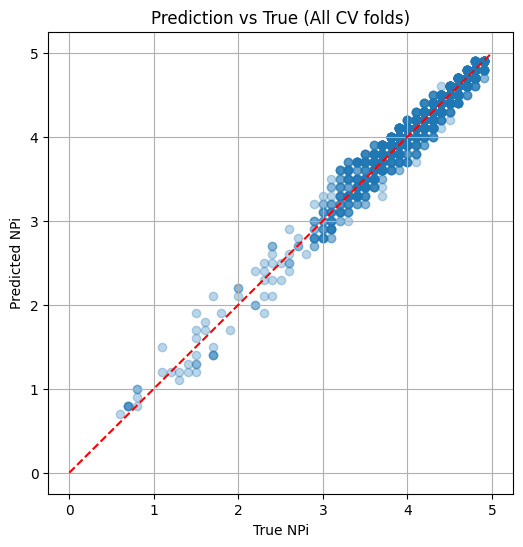

In [ ]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True (All CV folds)")
plt.grid()
plt.show()

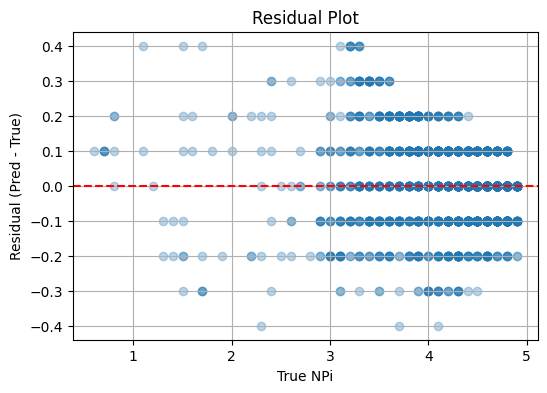

In [6]:
residuals = all_pred - all_true

plt.figure(figsize=(6,4))
plt.scatter(all_true, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()

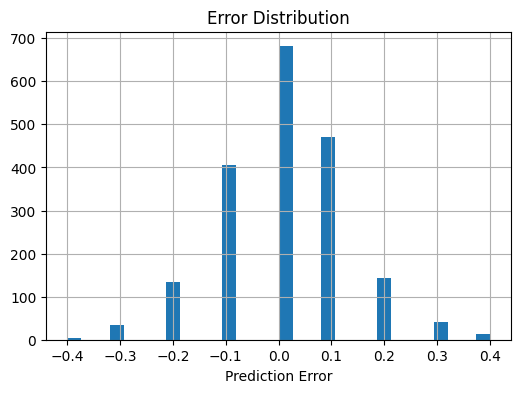

In [8]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()


# Final fit

In [ ]:
# Train on full data (Not using folds)
# Logit transform
y_scaled = np.clip(y_raw / 5, 1e-6, 1-1e-6)
z = np.log(y_scaled / (1 - y_scaled))

# Fit GAM
gam = LinearGAM(
    s(0, n_splines=20) +
    s(1, constraints='monotonic_dec', n_splines=10) +
    s(2, constraints='monotonic_inc', n_splines=10) +
    l(3) + l(4) + l(5) + l(6)
)

gam.gridsearch(X_trans, z)

x_vals_size = np.linspace(X_trans.iloc[:,0].min(), X_trans.iloc[:,0].max(), 200)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (200,1)),
    columns=X_trans.columns
)
X_fake.iloc[:,0] = x_vals_size

y_gam_size = gam.partial_dependence(term=0, X=X_fake)

params_size, _ = curve_fit(
    sigmoid_plus_threshold_linear,
    x_vals_size,
    y_gam_size,
    p0=[y_gam_size.max()-y_gam_size.min(), 1, np.median(x_vals_size), 0.2, y_gam_size.min(), 0],
    bounds=([0,0.01,x_vals_size.min(),-5,-10,x_vals_size.min()],
            [10,10,x_vals_size.max(),5,10,x_vals_size.max()]),
    maxfev=20000
)


x_vals_min = np.linspace(X_trans.iloc[:,1].min(), X_trans.iloc[:,1].max(), 200)

X_fake.iloc[:,1] = x_vals_min
y_gam_min = gam.partial_dependence(term=1, X=X_fake)

params_min, _ = curve_fit(exp_decay, x_vals_min, y_gam_min, maxfev=10000)


x_vals_ch = np.linspace(X_trans.iloc[:,2].min(), X_trans.iloc[:,2].max(), 200)

X_fake.iloc[:,2] = x_vals_ch
y_gam_ch = gam.partial_dependence(term=2, X=X_fake)

params_ch, _ = curve_fit(
    sigmoid_shifted,
    x_vals_ch,
    y_gam_ch,
    p0=[y_gam_ch.max()-y_gam_ch.min(), 1, np.median(x_vals_ch), y_gam_ch.min()],
    bounds=([0,0.01,x_vals_ch.min(),-10],
            [10,10,x_vals_ch.max(),10]),
    maxfev=20000
)

betas = np.array([
    gam.coef_[gam.terms.get_coef_indices(i)][0]
    for i in range(3,7)
])

intercept = (
    gam._modelmat(np.zeros((1, X_trans.shape[1]))) @ gam.coef_
).item()


def predict_z_full(X):
    return (
        intercept
        + sigmoid_plus_threshold_linear(X.iloc[:,0].values, *params_size)
        + exp_decay(X.iloc[:,1].values, *params_min)
        + sigmoid_shifted(X.iloc[:,2].values, *params_ch)
        + betas[0]*X.iloc[:,3].values
        + betas[1]*X.iloc[:,4].values
        + betas[2]*X.iloc[:,5].values
        + betas[3]*X.iloc[:,6].values
    )

z_pred = predict_z_full(X_trans)

reg = LinearRegression().fit(
    z_pred.reshape(-1,1),
    z
)

a = reg.coef_[0]
b = reg.intercept_

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


In [10]:
z_final = a * z_pred + b
y_pred = np.round(sigmoid(z_final) * 5,1)
rmse = np.sqrt(mean_squared_error(y_raw, y_pred))
mae  = mean_absolute_error(y_raw, y_pred)
r2   = r2_score(y_raw, y_pred)

print("\n=== PERFORMANCE ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


=== PERFORMANCE ===
RMSE: 0.1238
MAE:  0.0901
R2:   0.9638


In [ ]:
# Full feature model parameters
print("\n=== FINAL MODEL PARAMETERS ===")

print("\n--- SIZE ---")
print(dict(zip(
    ["A","k","x0","m","b","x_thresh"],
    params_size
)))

print("\n--- MIN ---")
print(dict(zip(["a","b","c"], params_min)))

print("\n--- CH ---")
print(dict(zip(["A","k","x0","b"], params_ch)))

print("\n--- LINEAR ---")
for i, beta in enumerate(betas):
    print(f"x{i+4}: {beta:.6f}")

print("\n--- INTERCEPT ---")
print(intercept)

print("\n--- CALIBRATION ---")
print(f"a = {a:.6f}, b = {b:.6f}")


=== FINAL MODEL PARAMETERS ===

--- SIZE ---
{'A': np.float64(9.999999999999998), 'k': np.float64(2.08255185622978), 'x0': np.float64(-3.415365703043776), 'm': np.float64(1.0685935066224426), 'b': np.float64(-9.904038566658652), 'x_thresh': np.float64(-0.6144288978520325)}

--- MIN ---
{'a': np.float64(6.149692217278926), 'b': np.float64(0.2579091232003132), 'c': np.float64(-6.602711355605647)}

--- CH ---
{'A': np.float64(1.154719690165307), 'k': np.float64(1.2021216346639305), 'x0': np.float64(-4.46909445858825), 'b': np.float64(-0.8511580254400347)}

--- LINEAR ---
x4: 0.016888
x5: -0.016207
x6: -0.001992
x7: -0.002749

--- INTERCEPT ---
1.6629856408750274

--- CALIBRATION ---
a = 0.920373, b = -0.562234


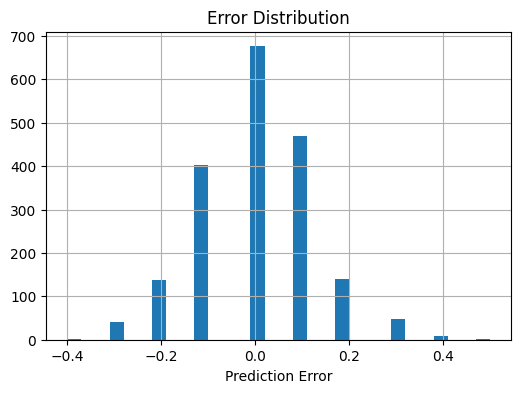

In [12]:
residuals = y_pred-y_raw
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()


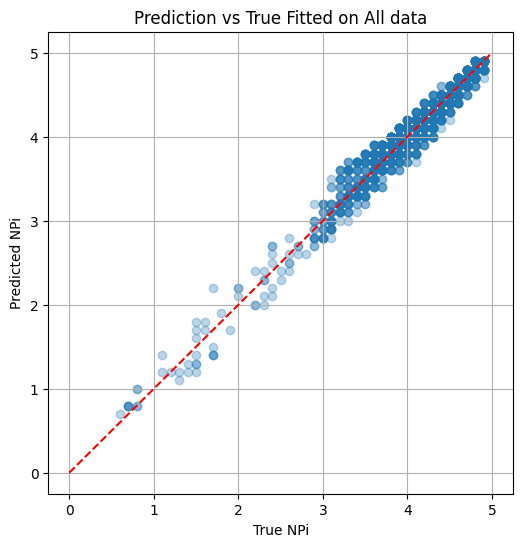

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(y_raw, y_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True Fitted on All data")
plt.grid()
plt.show()

In [15]:
results_all = pd.DataFrame({
    "record_id":              all_indices,
    "redcap_repeat_instance": all_repeat,
    "eye":                    all_eye,
    "y_true":                 all_true,
    "pred_a":                 all_pred
})
results_all.to_csv("predictions_all.csv", index=False)